This is a couple things in the MDTraj library and the hydrogen bonding module which can be located in the analysis references in the drop down menu (https://mdtraj.org/1.9.4/analysis.html). This library is used for tracking molecular trajectories which is the movement of atoms interating (for a fixed period of time) showing how the system evolves. A trajectory file (examples found here https://github.com/mdtraj/mdtraj/tree/master/docs/notebook-examples) is uploaded and stores fields that describe the system over time. The  specific module idenitifies hydrogen bonds and then calculates the distance of said bonds. One example of this library being used it

In [ ]:
import mdtraj as md
import matplotlib.pyplot as plt
import itertools

Then load a trajectory file (in this case a given example) into the notebook and print it out,

In [56]:
t = md.load_pdb('http://www.rcsb.org/pdb/files/2EQQ.pdb')
print(t)

<mdtraj.Trajectory with 20 frames, 423 atoms, 28 residues, without unitcells>


Next, call the function md.baker_hubbard to identity the hydrogen bonds and then print out the list of atoms

In [57]:
hbonds = md.baker_hubbard(t, periodic=False)

label = lambda hbond : '%s -- %s' % (t.topology.atom(hbond[0]), t.topology.atom(hbond[2]))
for hbond in hbonds:
     print(label(hbond))

GLU1-N -- GLU1-OE2
GLU1-N -- GLU1-OE1
GLY6-N -- SER4-O
CYS7-N -- GLY5-O
TYR11-N -- VAL8-O
MET12-N -- LYS20-O
ARG13-NH1 -- TYR11-O
THR14-N -- ARG18-O
ASP16-N -- ASP16-OD1
GLY17-N -- THR14-O
ARG18-N -- THR14-OG1
ARG18-NE -- ASP16-OD2
LYS20-N -- MET12-O
THR22-N -- GLY10-O
THR14-OG1 -- ASP16-OD1
THR28-OG1 -- ILE27-O


Then we can look at the distances with a historgram,

Text(0.5, 0, 'distance [nm]')

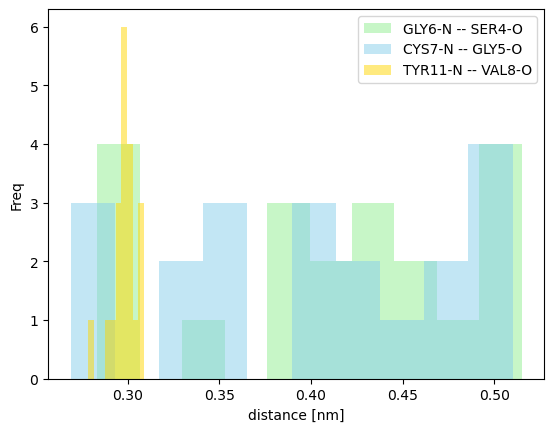

In [58]:
da_distances = md.compute_distances(t, hbonds[:, [0,2]], periodic=False)

color = itertools.cycle(['lightGreen', 'skyBlue', 'gold'])
for i in [2, 3, 4]:
    plt.hist(da_distances[:, i], color=next(color), label=label(hbonds[i]), alpha=0.5)
plt.legend()
plt.ylabel('Freq');
plt.xlabel('distance [nm]')

This starts to get at the physics question I am asking. 